Tugas 6 Mesin Learning
Nama : Alda Prahanika (23010050)
       Dea Azahwa Salsabila (23010055)
Kelas : 6TI-P2

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Analisis masalah dan Data

In [ ]:
# memasukan data yang sudah di drive
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [ ]:
# Menampilkan info pada data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None


In [ ]:
#Pengecekan nilai kosong atau missing value pada data
print(df.isnull().sum())

age           0
cp            0
trestbps      0
chol          0
fbs           0
restecg       0
thalach       0
exang         0
oldpeak       0
slope         0
ca            0
thal          0
target        0
sex_scaled    0
dtype: int64


2. Preprocessing

In [ ]:
#Langkah awal mengecek data column
print(df.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [ ]:
#Penerapan MinMaxScaler Pada Column sex
from sklearn.preprocessing import MinMaxScaler

# Inisialisasi MinMaxScaler
scaler = MinMaxScaler()

# Skalakan kolom 'sex' dan simpan hasilnya di kolom baru 'sex_scaled'
df['sex_scaled'] = scaler.fit_transform(df[['sex']])

# Menampilkan 5 baris pertama dengan kolom 'sex' dan 'sex_scaled' untuk verifikasi
print(df[['sex', 'sex_scaled']].head())

   sex  sex_scaled
0    1         1.0
1    1         1.0
2    1         1.0
3    1         1.0
4    0         0.0


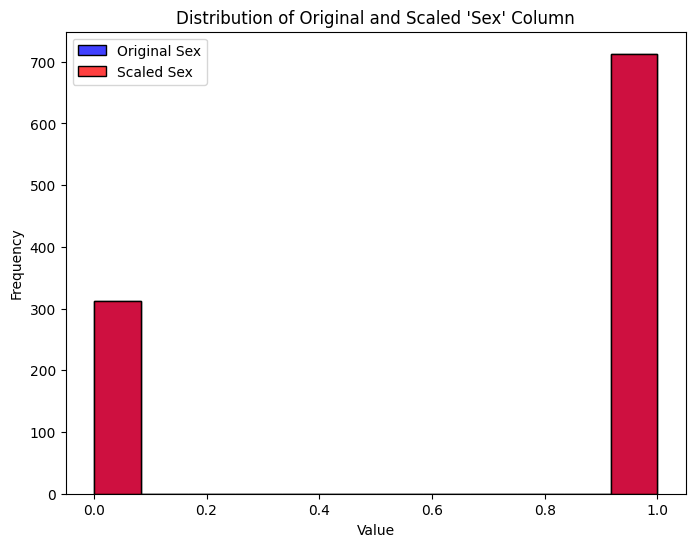

In [ ]:
#sebelum processing
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(df['sex'], color='blue', label='Original Sex', kde=False)
sns.histplot(df['sex_scaled'], color='red', label='Scaled Sex', kde=False)

#sesudah processing
plt.legend()
plt.title('Distribution of Original and Scaled \'Sex\' Column')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.show()

3. Pemilihan dan implementasi model

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 rows of X:\n", X.head())
print("First 5 rows of y:\n", y.head())

Shape of X: (1025, 14)
Shape of y: (1025,)
First 5 rows of X:
    age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  sex_scaled  
0   2     3         1.0  
1   0     3         1.0  
2   0     3         1.0  
3   1     3         1.0  
4   3     2         0.0  
First 5 rows of y:
 0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [ ]:
import pandas as pd

# Definisikan matriks fitur (X) dan vektor target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identifikasi kolom kategorikal yang tersisa dalam X (tidak termasuk 'sex' yang sudah dihapus dan 'sex_scaled' yang numerik)
# Asumsi kolom berikut adalah kategorikal berdasarkan deskripsi umum dataset ini
categorical_cols_for_ohe = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Lakukan One-Hot Encoding pada fitur kategorikal
X = pd.get_dummies(X, columns=categorical_cols_for_ohe, drop_first=True)

# Tampilkan bentuk matriks fitur (X) setelah One-Hot Encoding dan bentuknya
print("Bentuk matriks fitur (X) setelah One-Hot Encoding:", X.shape)
print("\n5 baris pertama dari matriks fitur (X) setelah One-Hot Encoding:")
print(X.head())

Bentuk matriks fitur (X) setelah One-Hot Encoding: (1025, 22)

5 baris pertama dari matriks fitur (X) setelah One-Hot Encoding:
   age  trestbps  chol  thalach  oldpeak  sex_scaled   cp_1   cp_2   cp_3  \
0   52       125   212      168      1.0         1.0  False  False  False   
1   53       140   203      155      3.1         1.0  False  False  False   
2   70       145   174      125      2.6         1.0  False  False  False   
3   61       148   203      161      0.0         1.0  False  False  False   
4   62       138   294      106      1.9         0.0  False  False  False   

   fbs_1  ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3   ca_4  thal_1  \
0  False  ...    False    False     True  False   True  False  False   False   
1   True  ...     True    False    False  False  False  False  False   False   
2  False  ...     True    False    False  False  False  False  False   False   
3  False  ...    False    False     True   True  False  False  False   False   
4   True 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk y_test: {y_test.shape}")

Bentuk X_train: (820, 22)
Bentuk X_test: (205, 22)
Bentuk y_train: (820,)
Bentuk y_test: (205,)


In [ ]:
# Definisikan matriks fitur (X) dan vektor target (y)
X = df.drop('target', axis=1)
y = df['target']

# Identifikasi kolom kategorikal yang tersisa dalam X (tidak termasuk 'sex' yang sudah dihapus dan 'sex_scaled' yang numerik)
# Asumsi kolom berikut adalah kategorikal berdasarkan deskripsi umum dataset ini
categorical_cols_for_ohe = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Lakukan One-Hot Encoding pada fitur kategorikal
X = pd.get_dummies(X, columns=categorical_cols_for_ohe, drop_first=True)

# Tampilkan 5 baris pertama dari X setelah One-Hot Encoding dan bentuknya
print("Bentuk matriks fitur (X) setelah One-Hot Encoding:", X.shape)
print("\n5 baris pertama dari matriks fitur (X) setelah One-Hot Encoding:")
print(X.head())

# Impor pustaka yang diperlukan untuk membagi data
from sklearn.model_selection import train_test_split

# Bagi data menjadi set pelatihan dan pengujian (80% pelatihan, 20% pengujian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Verifikasi bentuk set pelatihan dan pengujian
print(f"\nBentuk X_train: {X_train.shape}")
print(f"Bentuk X_test: {X_test.shape}")
print(f"Bentuk y_train: {y_train.shape}")
print(f"Bentuk y_test: {y_test.shape}")

# Impor model Regresi Logistik dan metrik evaluasi
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inisialisasi dan latih model Regresi Logistik
model = LogisticRegression(max_iter=1000, random_state=42) # Tingkatkan max_iter untuk konvergensi
model.fit(X_train, y_train)

# Buat prediksi pada set pengujian
y_pred = model.predict(X_test)

# Evaluasi kinerja model
print("\n--- Evaluasi Model Regresi Logistik ---")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print(f"\nAkurasi: {accuracy_score(y_test, y_pred):.4f}")

Bentuk matriks fitur (X) setelah One-Hot Encoding: (1025, 22)

5 baris pertama dari matriks fitur (X) setelah One-Hot Encoding:
   age  trestbps  chol  thalach  oldpeak  sex_scaled   cp_1   cp_2   cp_3  \
0   52       125   212      168      1.0         1.0  False  False  False   
1   53       140   203      155      3.1         1.0  False  False  False   
2   70       145   174      125      2.6         1.0  False  False  False   
3   61       148   203      161      0.0         1.0  False  False  False   
4   62       138   294      106      1.9         0.0  False  False  False   

   fbs_1  ...  exang_1  slope_1  slope_2   ca_1   ca_2   ca_3   ca_4  thal_1  \
0  False  ...    False    False     True  False   True  False  False   False   
1   True  ...     True    False    False  False  False  False  False   False   
2  False  ...     True    False    False  False  False  False  False   False   
3  False  ...    False    False     True   True  False  False  False   False   
4   True 

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Inisialisasi model K-Nearest Neighbors
# Kita bisa memulai dengan n_neighbors=5 sebagai nilai default
knn_model = KNeighborsClassifier(n_neighbors=5)

# Latih model menggunakan data pelatihan
knn_model.fit(X_train, y_train)

print("Model K-Nearest Neighbors berhasil dilatih.")

Model K-Nearest Neighbors berhasil dilatih.


4. Evaluasi

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat prediksi pada set pengujian menggunakan model KNN
y_pred_knn = knn_model.predict(X_test)

# Evaluasi kinerja model KNN
print("\n--- Evaluasi Model K-Nearest Neighbors ---")
print("\nLaporan Klasifikasi:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print(f"\nAkurasi: {accuracy_score(y_test, y_pred_knn):.4f}")


--- Evaluasi Model K-Nearest Neighbors ---

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.68      0.71      0.70       100
           1       0.71      0.69      0.70       105

    accuracy                           0.70       205
   macro avg       0.70      0.70      0.70       205
weighted avg       0.70      0.70      0.70       205


Confusion Matrix:
[[71 29]
 [33 72]]

Akurasi: 0.6976
